In [106]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
import nltk
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
import re
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud

In [55]:
df = pd.read_csv('https://raw.githubusercontent.com/Himanshu-1703/reddit-sentiment-analysis/refs/heads/main/data/reddit.csv')
df.head()

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


In [56]:
df.shape

(37249, 2)

In [57]:
df.sample()['clean_comment'].values

array(['this threat real they went for journalists they went for comedians they went for random satire writers and now they are going for cartoonists how long before they come for '],
      dtype=object)

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37249 entries, 0 to 37248
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   clean_comment  37149 non-null  object
 1   category       37249 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 582.1+ KB


In [59]:
df.isnull().sum()

clean_comment    100
category           0
dtype: int64

In [60]:
df[df['clean_comment'].isna()]

,clean_comment,category
413,NaN,0
605,NaN,0
2422,NaN,0
2877,NaN,0
3307,NaN,0
...,...,...
35975,NaN,0
36036,NaN,0
37043,NaN,0
37111,NaN,0


In [61]:
df = df.dropna()

In [62]:
df['category'].value_counts()

category
 1    15830
 0    13042
-1     8277
Name: count, dtype: int64

In [63]:
df.duplicated().sum()

np.int64(350)

In [64]:
df[df.duplicated()]

,clean_comment,category
375,,0
392,,0
617,aurum mom,0
651,,0
1222,,0
...,...,...
36915,who won,0
37044,,0
37125,hari,0
37158,top kek,1


In [65]:
df[(df['clean_comment'].str.strip() == '')]

,clean_comment,category
181,,0
375,,0
392,,0
651,,0
1222,,0
...,...,...
35711,,0
35778,,0
35987,,0
36707,,0


In [66]:
df = df[~(df['clean_comment'].str.strip() == '')]

In [67]:
df['clean_comment'] = df['clean_comment'].str.lower()

df.head()

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


In [68]:
df[df['clean_comment'].apply(lambda x:x.endswith(' ') or x.startswith(' '))]

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1
...,...,...
37241,let the janta decide not ulema clerics,0
37242,hona hai same with vaccination education insu...,0
37246,downvote karna tha par upvote hogaya,0
37247,haha nice,1


In [69]:
df['clean_comment'] = df['clean_comment'].str.strip()

df['clean_comment'].apply(lambda x:x.endswith(' ') or x.startswith(' ')).sum()

np.int64(0)

In [70]:
url_pattern = r'http[s]?://(?:[-\w.]|(?:%[\da-fA-F]{2}))+/?\S*'

comments_with_url = df['clean_comment'].str.contains(url_pattern,regex=True)

comments_with_url.value_counts()

clean_comment
False    37028
Name: count, dtype: int64

In [71]:
comments_with_newline = df[df['clean_comment'].str.contains('\n')]

comments_with_newline.head()

,clean_comment,category
448,what missing jpg\nand why this brilliant edit ...,1
781,india has been ruined congress and populist sc...,-1
847,like aap for its stand corruption and making p...,-1
871,reduced trade\ndeficit stronger rupee aren the...,0
1354,amsa press conference australian maritime safe...,1


In [72]:
df['clean_comment'] = df['clean_comment'].str.replace('\n',' ',regex=True)

comments_with_newline_remaining = df[df['clean_comment'].str.contains('\n')]

comments_with_newline_remaining.head()

,clean_comment,category


### EDA

<Axes: xlabel='category', ylabel='count'>

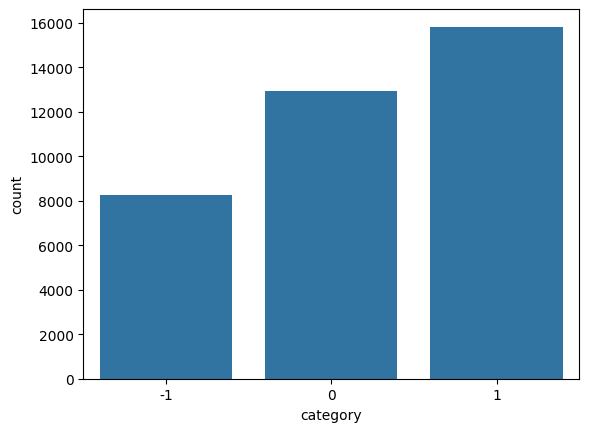

In [73]:
sns.countplot(data=df,x='category')

In [74]:
df['category'].value_counts(normalize=True).mul(100).round(2)

category
 1    42.75
 0    34.90
-1    22.35
Name: proportion, dtype: float64

In [75]:
df['word_count'] = df['clean_comment'].apply(lambda x:len(x.split()))

In [76]:
df.sample(5)

,clean_comment,category,word_count
4493,wtf shouldn first invest facilities and promot...,-1,15
24939,source written barc india isn barc bhabha atom...,0,22
6415,speaking shut dam son,0,4
27000,good hope indians kill themselves and “india” ...,1,12
34855,’ not just political parties indians generally...,1,16


In [77]:
df['word_count'].describe()

count    37028.000000
mean        29.499919
std         56.654363
min          1.000000
25%          6.000000
50%         13.000000
75%         30.000000
max       1307.000000
Name: word_count, dtype: float64

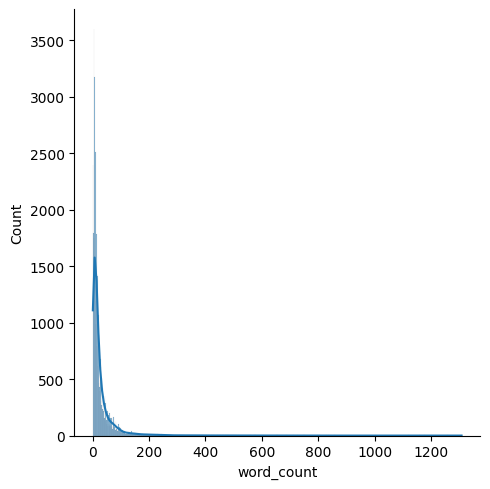

In [78]:
sns.displot(df['word_count'],kde=True)

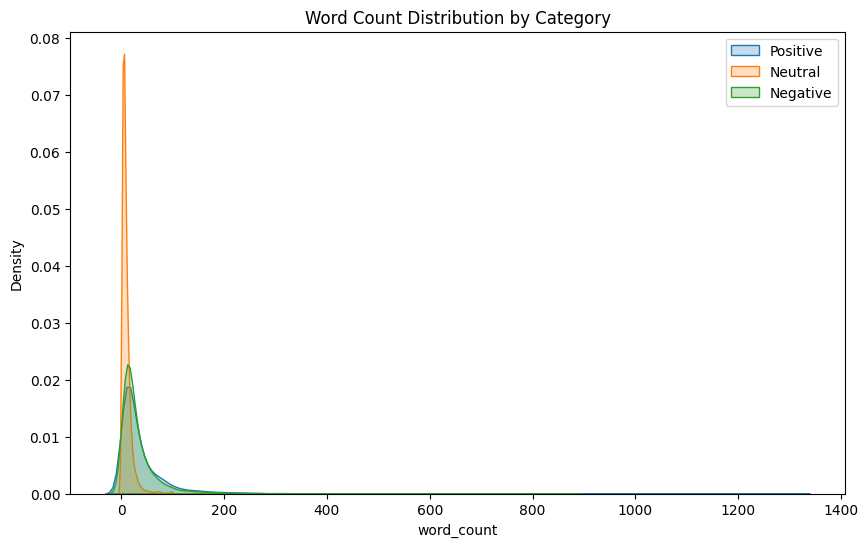

In [79]:
plt.figure(figsize=(10,6))

sns.kdeplot(df[df['category'] == 1]['word_count'],label='Positive',fill=True)
sns.kdeplot(df[df['category'] == 0]['word_count'],label='Neutral',fill=True)
sns.kdeplot(df[df['category'] == -1]['word_count'],label='Negative',fill=True)

plt.title('Word Count Distribution by Category')

plt.legend()

plt.show()

<Axes: ylabel='word_count'>

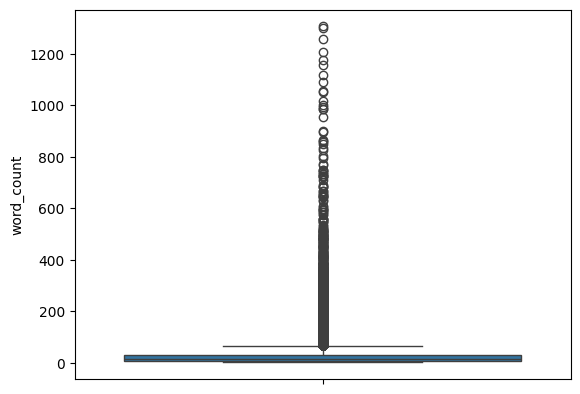

In [80]:
sns.boxplot(df['word_count'])

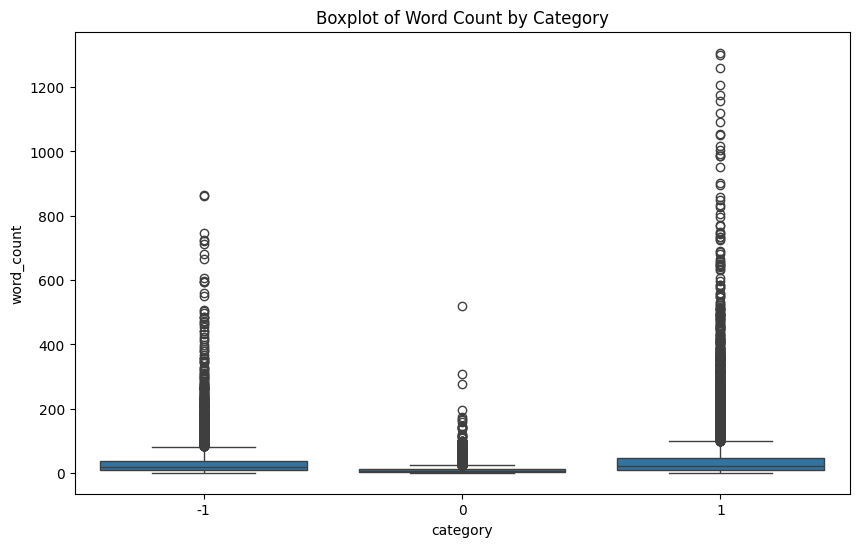

In [81]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df,x='category',y='word_count')
plt.title('Boxplot of Word Count by Category')
plt.show()

<Axes: xlabel='category', ylabel='word_count'>

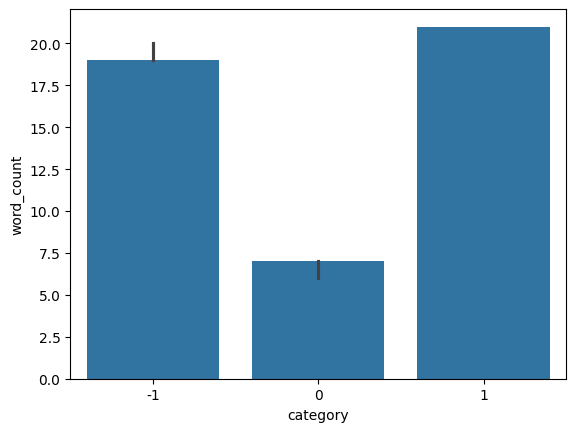

In [82]:
sns.barplot(df,x='category',y='word_count',estimator='median')

In [83]:
stop_words = set(stopwords.words('english'))

df['num_stop_words'] = df['clean_comment'].apply(lambda x: len([word for word in x.split() if word in stop_words]))

In [84]:
df.sample(5)

,clean_comment,category,word_count,num_stop_words
31860,hey that where live not the electric board off...,1,11,5
26428,how very calculated just before the elections,1,7,5
37041,read how ani has always been use the current g...,0,14,4
4767,wtf this awful faux pas his team they hired ch...,-1,23,10
23682,source seems the hindu isn the use government ...,0,23,8


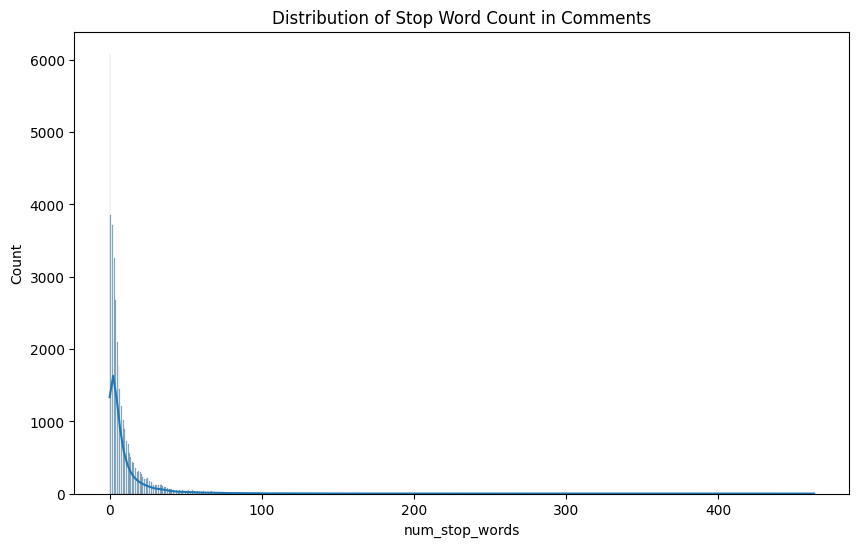

In [85]:
plt.figure(figsize=(10,6))

sns.histplot(df['num_stop_words'], kde=True)
plt.title('Distribution of Stop Word Count in Comments')
plt.show()

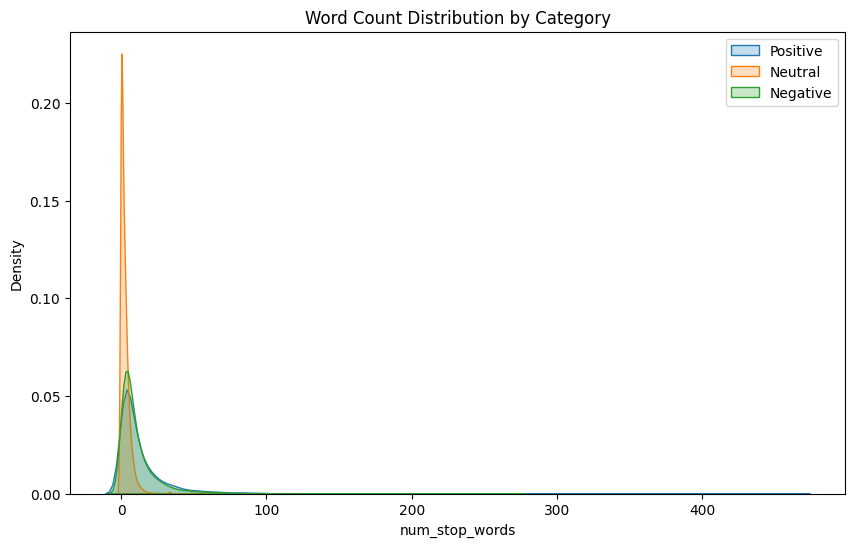

In [86]:
plt.figure(figsize=(10,6))

sns.kdeplot(df[df['category'] == 1]['num_stop_words'],label='Positive',fill=True)
sns.kdeplot(df[df['category'] == 0]['num_stop_words'],label='Neutral',fill=True)
sns.kdeplot(df[df['category'] == -1]['num_stop_words'],label='Negative',fill=True)

plt.title('Word Count Distribution by Category')

plt.legend()

plt.show()

<Axes: xlabel='category', ylabel='num_stop_words'>

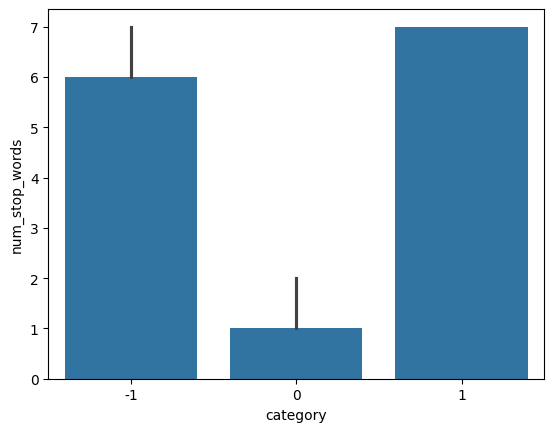

In [87]:
sns.barplot(df,x='category',y='num_stop_words',estimator='median')

C:\Users\TEST\AppData\Local\Temp\ipykernel_18276\3047377697.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_25_df_stop_words,x='count',y='stop_word',palette='viridis')


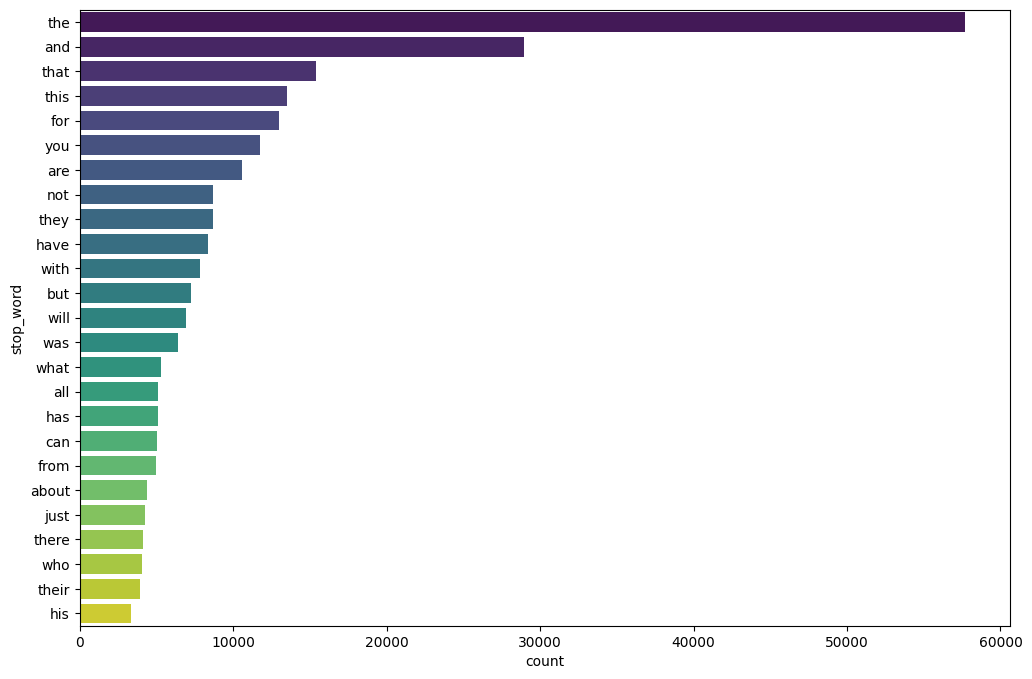

In [88]:
all_stop_words = [word for comment in df['clean_comment'] for word in comment.split() if word in stop_words]

most_common_stop_words = Counter(all_stop_words).most_common(25)

top_25_df_stop_words = pd.DataFrame(most_common_stop_words,columns=['stop_word','count'])

plt.figure(figsize=(12,8))
sns.barplot(data=top_25_df_stop_words,x='count',y='stop_word',palette='viridis')
plt.show()

In [89]:
df['num_chars'] = df['clean_comment'].apply(len)

df.head()

,clean_comment,category,word_count,num_stop_words,num_chars
0,family mormon have never tried explain them th...,1,39,13,259
1,buddhism has very much lot compatible with chr...,1,196,59,1268
2,seriously don say thing first all they won get...,-1,86,40,459
3,what you have learned yours and only yours wha...,0,29,15,167
4,for your own benefit you may want read living ...,1,112,45,690


In [90]:
df['num_chars'].describe()

count    37028.000000
mean       180.813303
std        358.823615
min          1.000000
25%         37.000000
50%         79.000000
75%        183.000000
max       8664.000000
Name: num_chars, dtype: float64

In [91]:
df[df['num_chars'] == 1]

,clean_comment,category,word_count,num_stop_words,num_chars
4601,☺,0,1,0,1
8490,\,0,1,0,1
19789,\,0,1,0,1
23056,\,0,1,0,1
24678,’,0,1,0,1
28030,\,0,1,0,1
29076,’,0,1,0,1
32430,\,0,1,0,1
32532,\,0,1,0,1
34312,\,0,1,0,1


In [92]:
all_text = ' '.join(df['clean_comment'])

char_frequency = Counter(all_text)

char_frequency_df = pd.DataFrame(char_frequency.items(),columns=['character','frequency']).sort_values(by='frequency',ascending=False)

In [93]:
char_frequency_df['character'].values

array([' ', 'e', 't', ..., '段', '她', '谁'], shape=(1378,), dtype=object)

In [94]:
char_frequency_df['character'].tail(50)

1286    货
1287    语
1312    耐
1313    精
342     ━
345     ⊂
346     ゜
347     ｊ
1289    显
1291    鞋
1292    峰
1293    期
1295    带
1296    搬
1297    板
1277    健
1278    停
1279    闹
1317    拖
1371    ׃
1372    ജ
1333    抹
1334    掉
1335    坛
1336    回
1353    ڈ
1355    پ
1356    ڑ
1357    آ
1360    ֹ
1376    т
1299    角
1300    衰
1350    ూ
1373    ണ
1374    р
1375    ч
1337    毫
1338    违
1339    逍
1340    遥
1341    则
1342    豹
1343    皿
1344    煮
1345    唯
1346    统
1330    段
1331    她
1332    谁
Name: character, dtype: object

In [95]:
df['num_punctuation_chars'] = df['clean_comment'].apply(
    lambda x: sum([1 for char in x if char in '.,!?:"\'()[]{}-'])
)

df.sample(5)

,clean_comment,category,word_count,num_stop_words,num_chars,num_punctuation_chars
8572,does anyone else liken this the invasion frenc...,-1,17,4,109,0
25446,what the context your prostrations you want ng...,1,115,34,745,0
4241,sab andar lolguard jag uthega,0,5,0,29,0
3158,agar aap ilake kachra nahi hai hamare city aai...,0,15,0,84,0
15725,keep doing this and time will come when folk w...,0,21,9,118,0


In [96]:
df['num_punctuation_chars'].describe()

count    37028.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: num_punctuation_chars, dtype: float64

C:\Users\TEST\AppData\Local\Temp\ipykernel_18276\4188861777.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_25_bigrams_df,x='count',y='bigram',palette='viridis')


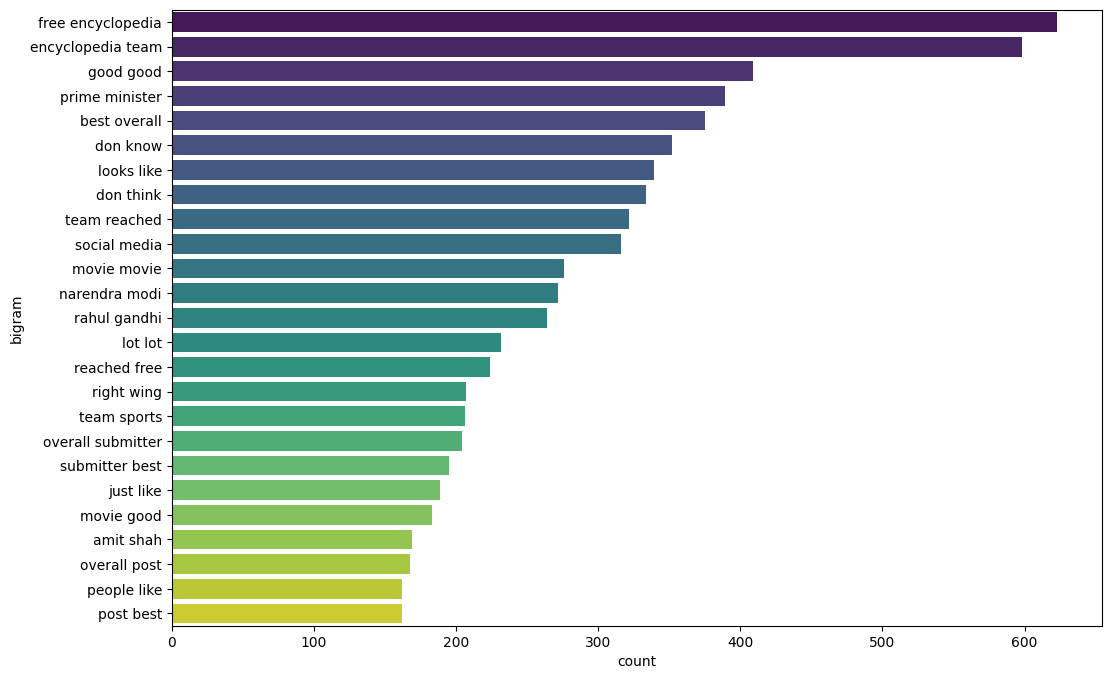

In [97]:
def get_top_ngrams(corpus,n=None):
    vec = CountVectorizer(ngram_range=(2,2),stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word,sum_words[0,idx]) for word,idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x:x[1],reverse=True)
    return words_freq[:n]


top_25_bigrams = get_top_ngrams(df['clean_comment'],25)
top_25_bigrams_df = pd.DataFrame(top_25_bigrams,columns=['bigram','count'])



plt.figure(figsize=(12,8))
sns.barplot(data=top_25_bigrams_df,x='count',y='bigram',palette='viridis')
plt.show()

C:\Users\TEST\AppData\Local\Temp\ipykernel_18276\3550011935.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_25_trigrams_df,x='count',y='trigram',palette='viridis')


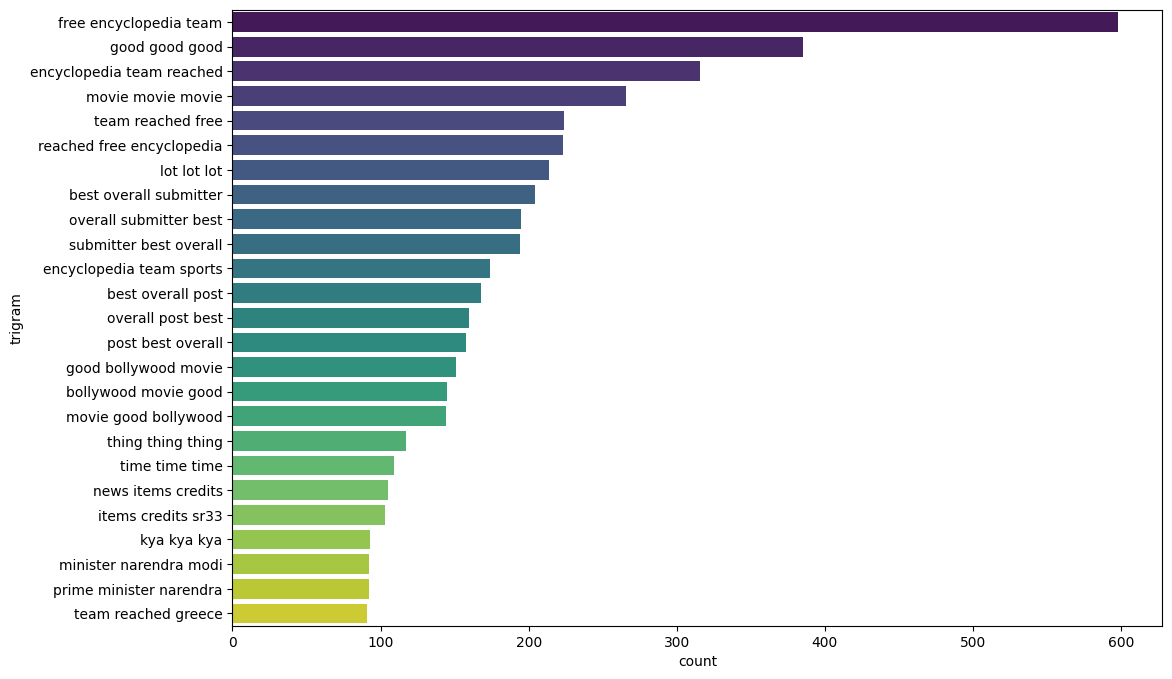

In [98]:
def get_top_trigrams(corpus,n=None):
    vec = CountVectorizer(ngram_range=(3,3),stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word,sum_words[0,idx]) for word,idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x:x[1],reverse=True)
    return words_freq[:n]


top_25_trigrams = get_top_trigrams(df['clean_comment'],25)
top_25_trigrams_df = pd.DataFrame(top_25_trigrams,columns=['trigram','count'])



plt.figure(figsize=(12,8))
sns.barplot(data=top_25_trigrams_df,x='count',y='trigram',palette='viridis')
plt.show()

In [99]:
df['clean_comment'] = df['clean_comment'].apply(lambda x:re.sub(r'[^A-Za-z0-9\s!?.,]','',str(x)))

In [100]:
all_text = ' '.join(df['clean_comment'])

char_frequency = Counter(all_text)

char_frequency_df = pd.DataFrame(char_frequency.items(),columns=['character','frequency']).sort_values(by='frequency',ascending=False)

char_frequency_df

,character,frequency
6,,1092360
12,e,667025
13,t,491655
1,a,481442
3,i,401612
9,n,388677
7,o,380205
17,s,355521
8,r,331588
10,h,296971


In [101]:
df.head()

,clean_comment,category,word_count,num_stop_words,num_chars,num_punctuation_chars
0,family mormon have never tried explain them th...,1,39,13,259,0
1,buddhism has very much lot compatible with chr...,1,196,59,1268,0
2,seriously don say thing first all they won get...,-1,86,40,459,0
3,what you have learned yours and only yours wha...,0,29,15,167,0
4,for your own benefit you may want read living ...,1,112,45,690,0


In [102]:
stop_words = set(stopwords.words('english')) - {'not','but','however','no','yet'}

df['clean_comment'] = df['clean_comment'].apply(
    lambda x: ' '.join([word for word in x.split() if word.lower() not in stop_words])
)

In [103]:
df.head()

,clean_comment,category,word_count,num_stop_words,num_chars,num_punctuation_chars
0,family mormon never tried explain still stare ...,1,39,13,259,0
1,buddhism much lot compatible christianity espe...,1,196,59,1268,0
2,seriously say thing first get complex explain ...,-1,86,40,459,0
3,learned want teach different focus goal not wr...,0,29,15,167,0
4,benefit may want read living buddha living chr...,1,112,45,690,0


In [104]:
lemmatizer = WordNetLemmatizer()


df['clean_comment'] = df['clean_comment'].apply(
    lambda x: ' '.join([lemmatizer.lemmatize(word) for word in x.split()])
)

df.head()

,clean_comment,category,word_count,num_stop_words,num_chars,num_punctuation_chars
0,family mormon never tried explain still stare ...,1,39,13,259,0
1,buddhism much lot compatible christianity espe...,1,196,59,1268,0
2,seriously say thing first get complex explain ...,-1,86,40,459,0
3,learned want teach different focus goal not wr...,0,29,15,167,0
4,benefit may want read living buddha living chr...,1,112,45,690,0


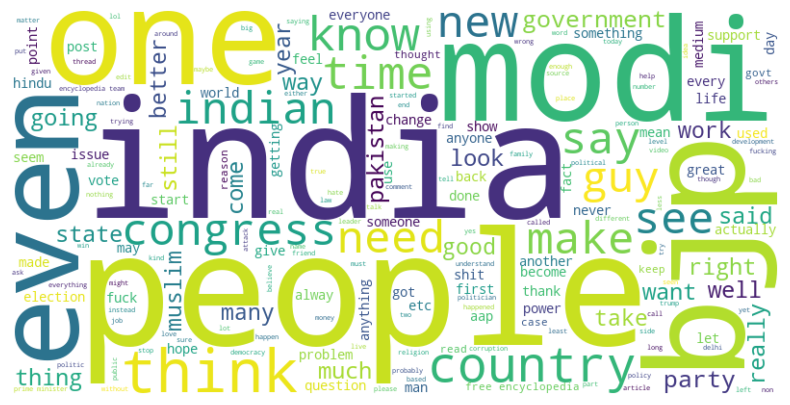

In [107]:
def plot_word_cloud(text):
    wordcloud = WordCloud(width=800,height=400,background_color='white').generate(' '.join(text))
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud,interpolation='bilinear')
    plt.axis('off')
    plt.show()

plot_word_cloud(df['clean_comment'])

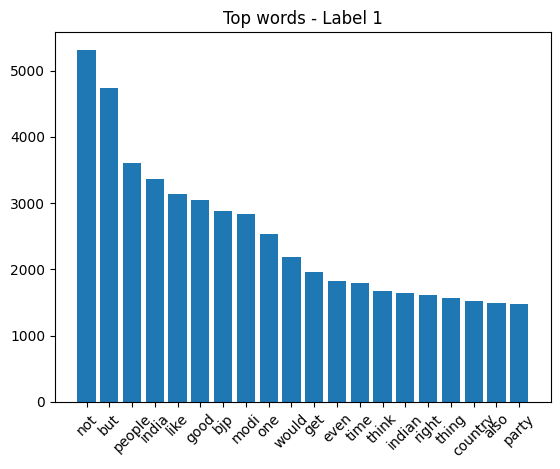

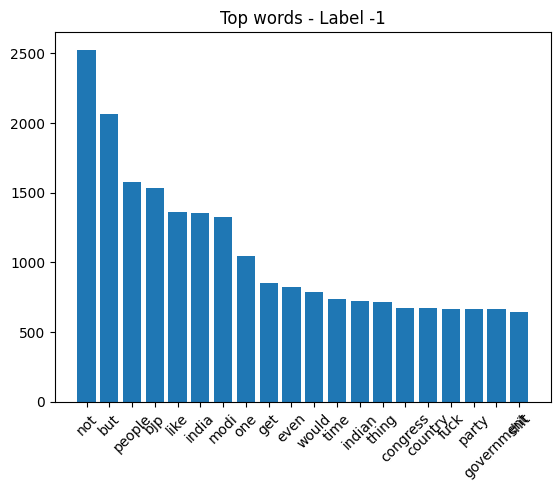

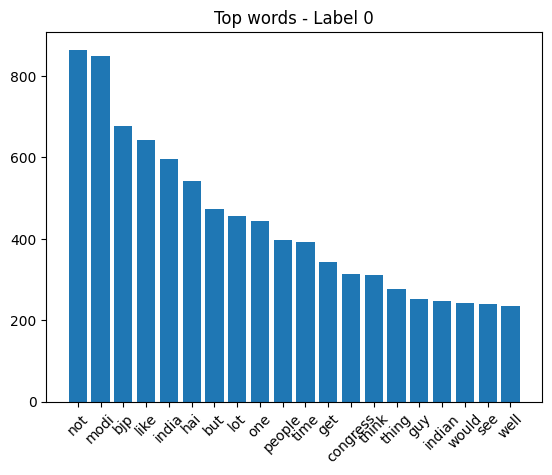

In [108]:
labels = df['category'].unique()

for label in labels:
    
    texts = df[df['category'] == label]['clean_comment']
    
    all_words = []
    
    for text in texts:
        words = re.findall(r'\b\w+\b', text.lower())
        all_words.extend(words)
    
    counter = Counter(all_words)
    most_common = counter.most_common(20)
    
    words = [w for w, c in most_common]
    counts = [c for w, c in most_common]
    
    plt.figure()
    plt.bar(words, counts)
    plt.title(f'Top words - Label {label}')
    plt.xticks(rotation=45)
    plt.show()